In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.subplots import make_subplots
from datetime import datetime

In [2]:
covid_df =pd.read_csv(r"C:\Users\HP\Downloads\Covid-19-Data-Analysis-Project-Using-Python-And-Tableau-main\Covid-19-Data-Analysis-Project-Using-Python-And-Tableau-main\covid_19_india.csv",sep=',')

In [3]:
cols_to_remove = ['Sno','ConfirmedIndianNational','ConfirmedForeignNational']
covid_df= covid_df.drop(columns=cols_to_remove)

In [4]:
covid_df.drop(columns=['Time'],inplace= True)

In [5]:
covid_df.head(10)

,Date,State/UnionTerritory,Cured,Deaths,Confirmed
0,2020-01-30,Kerala,0.0,0.0,1.0
1,2020-01-31,Kerala,0.0,0.0,1.0
2,2020-02-01,Kerala,0.0,0.0,2.0
3,2020-02-02,Kerala,0.0,0.0,3.0
4,2020-02-03,Kerala,0.0,0.0,3.0
5,2020-02-04,Kerala,0.0,0.0,3.0
6,2020-02-05,Kerala,0.0,0.0,3.0
7,2020-02-06,Kerala,0.0,0.0,3.0
8,2020-02-07,Kerala,0.0,0.0,3.0
9,2020-02-08,Kerala,0.0,0.0,3.0


In [6]:
covid_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15114 entries, 0 to 15113
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  15086 non-null  object 
 1   State/UnionTerritory  15086 non-null  object 
 2   Cured                 15086 non-null  float64
 3   Deaths                15086 non-null  float64
 4   Confirmed             15086 non-null  float64
dtypes: float64(3), object(2)
memory usage: 590.5+ KB


In [7]:
covid_df.describe()

,Cured,Deaths,Confirmed
count,1.508600e+04,15086.000000,1.508600e+04
mean,1.747937e+05,2721.084449,1.942820e+05
std,3.648330e+05,7182.672358,4.095184e+05
min,0.000000e+00,0.000000,0.000000e+00
25%,1.685000e+03,12.000000,2.935500e+03
50%,1.964700e+04,364.000000,2.608150e+04
75%,2.087552e+05,2170.000000,2.216012e+05
max,4.927480e+06,83777.000000,5.433506e+06


In [8]:
vaccine_df= pd.read_csv (r"C:\Users\HP\Downloads\Covid-19-Data-Analysis-Project-Using-Python-And-Tableau-main\Covid-19-Data-Analysis-Project-Using-Python-And-Tableau-main\covid_vaccine_statewise.csv",sep=',')

In [9]:
#fill all missing values with 0
vaccine_df.fillna(0,inplace = True)

In [10]:
vaccine_df.head(7)

,Updated On,State,Total Doses Administered,Sessions,Sites,First Dose Administered,Second Dose Administered,Male (Doses Administered),Female (Doses Administered),Transgender (Doses Administered),...,18-44 Years (Doses Administered),45-60 Years (Doses Administered),60+ Years (Doses Administered),18-44 Years(Individuals Vaccinated),45-60 Years(Individuals Vaccinated),60+ Years(Individuals Vaccinated),Male(Individuals Vaccinated),Female(Individuals Vaccinated),Transgender(Individuals Vaccinated),Total Individuals Vaccinated
0,16/01/2021,India,48276.0,3455.0,2957.0,48276.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,23757.0,24517.0,2.0,48276.0
1,17/01/2021,India,58604.0,8532.0,4954.0,58604.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,27348.0,31252.0,4.0,58604.0
2,18/01/2021,India,99449.0,13611.0,6583.0,99449.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,41361.0,58083.0,5.0,99449.0
3,19/01/2021,India,195525.0,17855.0,7951.0,195525.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,81901.0,113613.0,11.0,195525.0
4,20/01/2021,India,251280.0,25472.0,10504.0,251280.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,98111.0,153145.0,24.0,251280.0
5,21/01/2021,India,365965.0,32226.0,12600.0,365965.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,132784.0,233143.0,38.0,365965.0
6,22/01/2021,India,549381.0,36988.0,14115.0,549381.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,193899.0,355402.0,80.0,549381.0


In [11]:
#drop rows where any value is missing
vaccine_df.dropna(inplace= True)

In [12]:
covid_df.drop(["Sno","Time","ConfirmedIndianNational","ConfirmedForeignNational"],inplace = True,axis =1,errors ='ignore')

In [13]:
covid_df.head()

,Date,State/UnionTerritory,Cured,Deaths,Confirmed
0,2020-01-30,Kerala,0.0,0.0,1.0
1,2020-01-31,Kerala,0.0,0.0,1.0
2,2020-02-01,Kerala,0.0,0.0,2.0
3,2020-02-02,Kerala,0.0,0.0,3.0
4,2020-02-03,Kerala,0.0,0.0,3.0


In [14]:
covid_df['Date']=pd.to_datetime(covid_df['Date'],format ='%Y-%m-%d')

In [15]:
covid_df.head()

,Date,State/UnionTerritory,Cured,Deaths,Confirmed
0,2020-01-30,Kerala,0.0,0.0,1.0
1,2020-01-31,Kerala,0.0,0.0,1.0
2,2020-02-01,Kerala,0.0,0.0,2.0
3,2020-02-02,Kerala,0.0,0.0,3.0
4,2020-02-03,Kerala,0.0,0.0,3.0


In [16]:
#this removes rows where all values are missing 
covid_df.dropna(how ='all',inplace=True)

In [17]:
#active cases
covid_df['Active_Cases'] =covid_df['Confirmed'] - (covid_df['Cured']+ covid_df['Deaths'])
covid_df.tail()

,Date,State/UnionTerritory,Cured,Deaths,Confirmed,Active_Cases
15081,2021-05-19,Telangana,485644.0,3012.0,536766.0,48110.0
15082,2021-05-19,Tripura,36402.0,450.0,42776.0,5924.0
15083,2021-05-19,Uttarakhand,214426.0,5132.0,295790.0,76232.0
15084,2021-05-19,Uttar Pradesh,1483249.0,18072.0,1637663.0,136342.0
15085,2021-05-19,West Bengal,1026492.0,13576.0,1171861.0,131793.0


In [18]:
statewise =pd.pivot_table(covid_df ,values =["Confirmed","Deaths","Cured"],index = "State/UnionTerritory", aggfunc = "max")

In [19]:
statewise["Recovery Rate"] = statewise["Cured"]*100/statewise["Confirmed"]

In [20]:
statewise["Mortality Rate"] = statewise["Deaths"]*100/statewise["Confirmed"]

In [21]:
statewise = statewise.sort_values(by ="Confirmed" , ascending = False)

In [22]:
statewise.style.background_gradient(cmap = "cubehelix")

,Confirmed,Cured,Deaths,Recovery Rate,Mortality Rate
State/UnionTerritory,,,,,
Maharashtra,5433506.000000,4927480.000000,83777.000000,90.686934,1.541859
Karnataka,2272374.000000,1674487.000000,22838.000000,73.688882,1.005028
Kerala,2200706.000000,1846105.000000,6612.000000,83.886944,0.300449
Tamil Nadu,1664350.000000,1403052.000000,18369.000000,84.300297,1.103674
Uttar Pradesh,1637663.000000,1483249.000000,18072.000000,90.571076,1.103524
Andhra Pradesh,1475372.000000,1254291.000000,9580.000000,85.015237,0.649328
Delhi,1402873.000000,1329899.000000,22111.000000,94.798246,1.576123
West Bengal,1171861.000000,1026492.000000,13576.000000,87.595030,1.158499
Chhattisgarh,925531.000000,823113.000000,12036.000000,88.934136,1.300443


In [23]:
#top 10 active cases
top_10_active_cases = covid_df.groupby(by ='State/UnionTerritory').max()[['Active_Cases','Date',]].sort_values(by =
            ['Active_Cases'], ascending = False).reset_index()
                                                                                    

In [24]:
fig = plt.figure(figsize = (16,9))

<Figure size 1600x900 with 0 Axes>

Text(0.5, 1.0, 'Top 10 states with active cases in India')

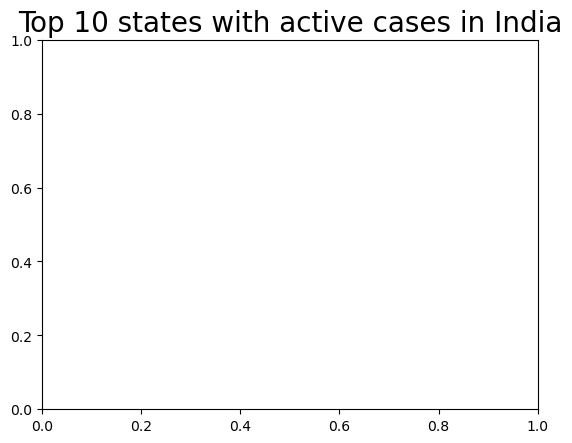

In [25]:
plt.title("Top 10 states with active cases in India",size = 20) 

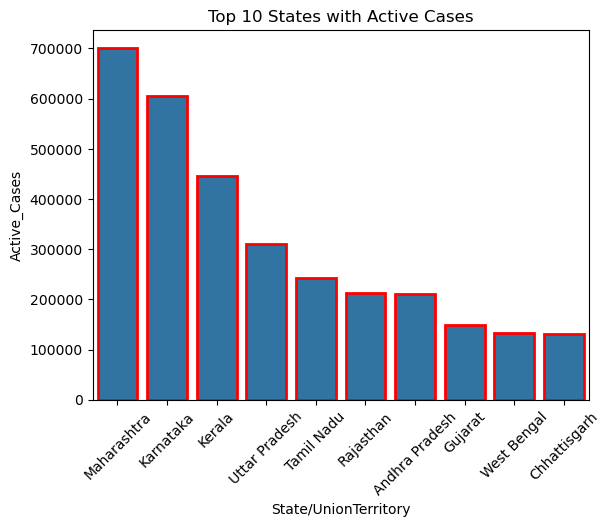

In [26]:
ax = sns.barplot(data = top_10_active_cases.iloc[:10],y= "Active_Cases", x = "State/UnionTerritory",linewidth = 2,edgecolor = 'red')
#x-axis labels
plt.xticks(rotation = 45)
plt.title("Top 10 States with Active Cases")
plt.show()

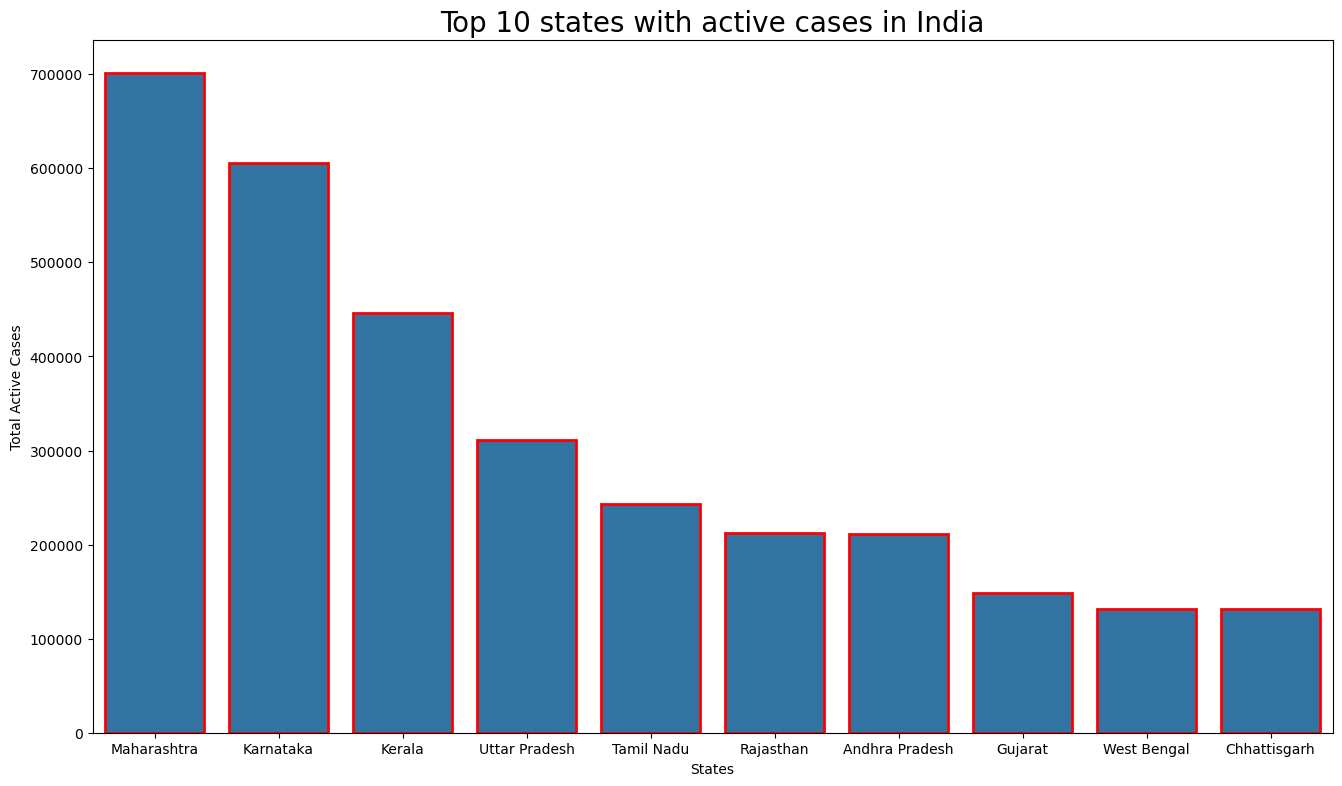

In [27]:
top_10_active_cases = covid_df.groupby(by ='State/UnionTerritory').max()[['Active_Cases','Date',]].sort_values(by =
            ['Active_Cases'], ascending = False).reset_index()
fig = plt.figure(figsize = (16,9))
plt.title("Top 10 states with active cases in India",size = 20)
ax = sns.barplot(data = top_10_active_cases.iloc[:10],y= "Active_Cases", x = "State/UnionTerritory",linewidth = 2,edgecolor = 'red')
plt.xlabel ("States")
plt.ylabel ("Total Active Cases")
plt.show()

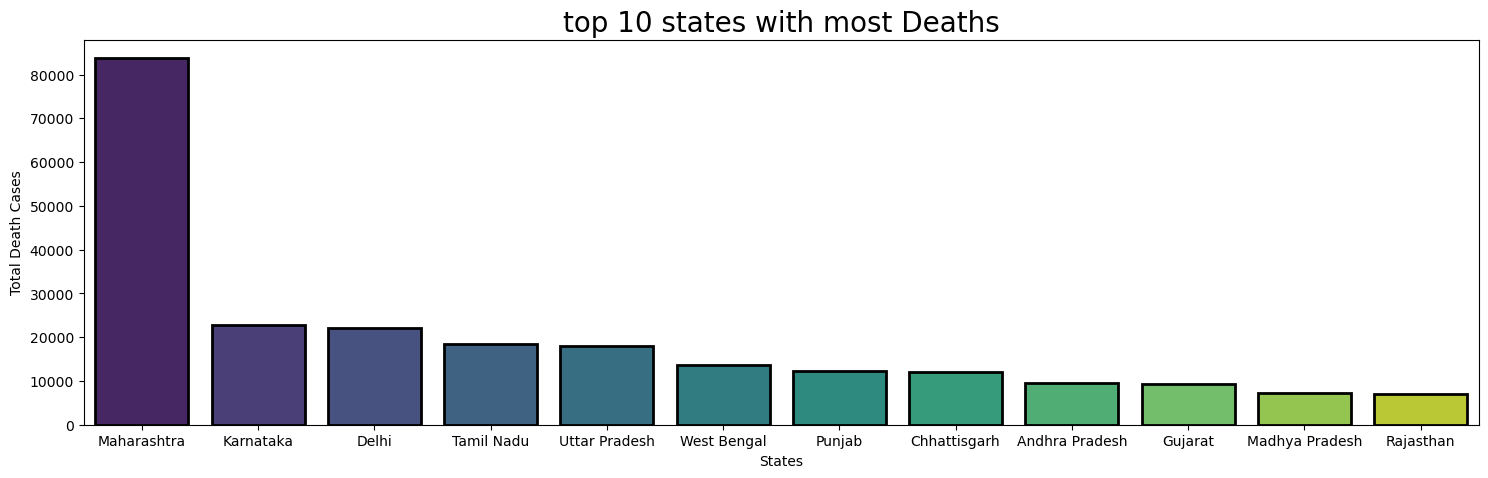

In [28]:
# top states with highest deaths
top_10_deaths = covid_df.groupby (by = 'State/UnionTerritory').max()[['Deaths','Date']].sort_values(by =['Deaths'],ascending = False).reset_index()
fig =plt.figure(figsize = (18,5))
plt.title("top 10 states with most Deaths", size =20) 
ax = sns.barplot(data = top_10_deaths.iloc [:12], y = "Deaths",x = "State/UnionTerritory" ,hue ="State/UnionTerritory",legend =False ,linewidth = 2,edgecolor = 'black',palette ='viridis')
plt.xlabel("States")
plt.ylabel("Total Death Cases")
plt.show()

In [29]:
covid_df ['Date'] = pd.to_datetime(covid_df['Date'])
covid_df = covid_df.sort_values(by = 'Date')


Text(0.5, 1.0, 'Top 5 Affected states in India')

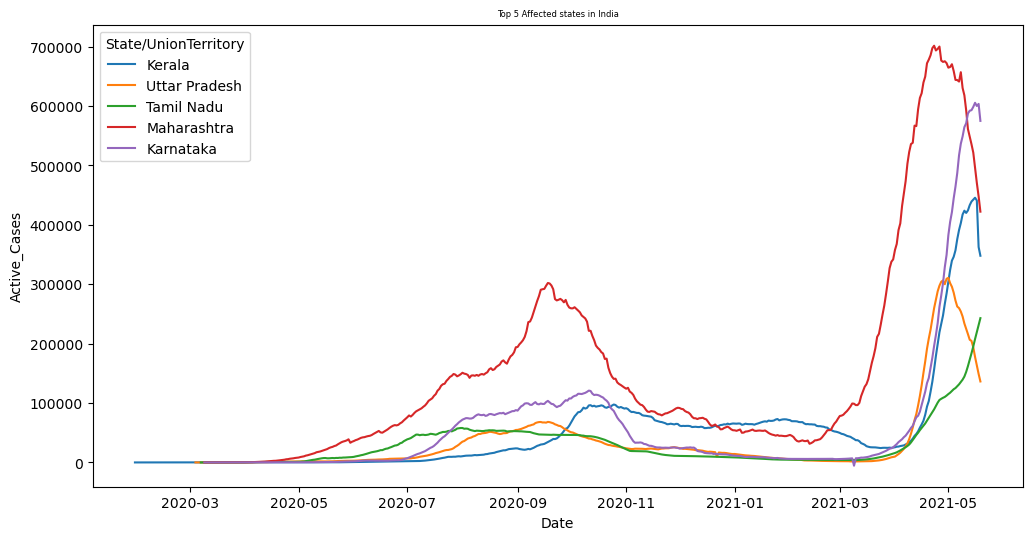

In [30]:
# growth trend 
fig = plt.figure(figsize = (12,6))
ax = sns.lineplot(data = covid_df[covid_df['State/UnionTerritory'].isin(['Maharashtra','Karnataka','Kerala','Tamil Nadu','Uttar Pradesh'])],
    x = 'Date', y = 'Active_Cases', hue ='State/UnionTerritory')
ax.set_title("Top 5 Affected states in India", size = 6)

In [31]:
vaccine_df.head()

,Updated On,State,Total Doses Administered,Sessions,Sites,First Dose Administered,Second Dose Administered,Male (Doses Administered),Female (Doses Administered),Transgender (Doses Administered),...,18-44 Years (Doses Administered),45-60 Years (Doses Administered),60+ Years (Doses Administered),18-44 Years(Individuals Vaccinated),45-60 Years(Individuals Vaccinated),60+ Years(Individuals Vaccinated),Male(Individuals Vaccinated),Female(Individuals Vaccinated),Transgender(Individuals Vaccinated),Total Individuals Vaccinated
0,16/01/2021,India,48276.0,3455.0,2957.0,48276.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,23757.0,24517.0,2.0,48276.0
1,17/01/2021,India,58604.0,8532.0,4954.0,58604.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,27348.0,31252.0,4.0,58604.0
2,18/01/2021,India,99449.0,13611.0,6583.0,99449.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,41361.0,58083.0,5.0,99449.0
3,19/01/2021,India,195525.0,17855.0,7951.0,195525.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,81901.0,113613.0,11.0,195525.0
4,20/01/2021,India,251280.0,25472.0,10504.0,251280.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,98111.0,153145.0,24.0,251280.0


In [32]:
vaccine_df.rename(columns = {'updated on' : 'vaccine_Date'}, inplace = True)

In [33]:
vaccine_df.head(10)


,Updated On,State,Total Doses Administered,Sessions,Sites,First Dose Administered,Second Dose Administered,Male (Doses Administered),Female (Doses Administered),Transgender (Doses Administered),...,18-44 Years (Doses Administered),45-60 Years (Doses Administered),60+ Years (Doses Administered),18-44 Years(Individuals Vaccinated),45-60 Years(Individuals Vaccinated),60+ Years(Individuals Vaccinated),Male(Individuals Vaccinated),Female(Individuals Vaccinated),Transgender(Individuals Vaccinated),Total Individuals Vaccinated
0,16/01/2021,India,48276.0,3455.0,2957.0,48276.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,23757.0,24517.0,2.0,48276.0
1,17/01/2021,India,58604.0,8532.0,4954.0,58604.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,27348.0,31252.0,4.0,58604.0
2,18/01/2021,India,99449.0,13611.0,6583.0,99449.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,41361.0,58083.0,5.0,99449.0
3,19/01/2021,India,195525.0,17855.0,7951.0,195525.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,81901.0,113613.0,11.0,195525.0
4,20/01/2021,India,251280.0,25472.0,10504.0,251280.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,98111.0,153145.0,24.0,251280.0
5,21/01/2021,India,365965.0,32226.0,12600.0,365965.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,132784.0,233143.0,38.0,365965.0
6,22/01/2021,India,549381.0,36988.0,14115.0,549381.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,193899.0,355402.0,80.0,549381.0
7,23/01/2021,India,759008.0,43076.0,15605.0,759008.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,267856.0,491049.0,103.0,759008.0
8,24/01/2021,India,835058.0,49851.0,18111.0,835058.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,296283.0,538647.0,128.0,835058.0
9,25/01/2021,India,1277104.0,55151.0,19682.0,1277104.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,444137.0,832766.0,201.0,1277104.0


In [34]:
vaccine_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7845 entries, 0 to 7844
Data columns (total 24 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Updated On                           7845 non-null   object 
 1   State                                7845 non-null   object 
 2   Total Doses Administered             7845 non-null   float64
 3   Sessions                             7845 non-null   float64
 4    Sites                               7845 non-null   float64
 5   First Dose Administered              7845 non-null   float64
 6   Second Dose Administered             7845 non-null   float64
 7   Male (Doses Administered)            7845 non-null   float64
 8   Female (Doses Administered)          7845 non-null   float64
 9   Transgender (Doses Administered)     7845 non-null   float64
 10   Covaxin (Doses Administered)        7845 non-null   float64
 11  CoviShield (Doses Administered

In [35]:
vaccine_df.isnull().sum()

Updated On                             0
State                                  0
Total Doses Administered               0
Sessions                               0
 Sites                                 0
First Dose Administered                0
Second Dose Administered               0
Male (Doses Administered)              0
Female (Doses Administered)            0
Transgender (Doses Administered)       0
 Covaxin (Doses Administered)          0
CoviShield (Doses Administered)        0
Sputnik V (Doses Administered)         0
AEFI                                   0
18-44 Years (Doses Administered)       0
45-60 Years (Doses Administered)       0
60+ Years (Doses Administered)         0
18-44 Years(Individuals Vaccinated)    0
45-60 Years(Individuals Vaccinated)    0
60+ Years(Individuals Vaccinated)      0
Male(Individuals Vaccinated)           0
Female(Individuals Vaccinated)         0
Transgender(Individuals Vaccinated)    0
Total Individuals Vaccinated           0
dtype: int64

In [36]:
vaccination = vaccine_df.drop(columns = ['Sputnik V(Doses Administered)','AEFI ','18-44 Years (Doses Administered)','45-60 Years(Doses Administered)','60+ Years (Doses Administered)'],axis=1,errors ='ignore')

In [37]:
#run this to see exact column names
print(vaccination.columns.tolist())

['Updated On', 'State', 'Total Doses Administered', 'Sessions', ' Sites ', 'First Dose Administered', 'Second Dose Administered', 'Male (Doses Administered)', 'Female (Doses Administered)', 'Transgender (Doses Administered)', ' Covaxin (Doses Administered)', 'CoviShield (Doses Administered)', 'Sputnik V (Doses Administered)', 'AEFI', '45-60 Years (Doses Administered)', '18-44 Years(Individuals Vaccinated)', '45-60 Years(Individuals Vaccinated)', '60+ Years(Individuals Vaccinated)', 'Male(Individuals Vaccinated)', 'Female(Individuals Vaccinated)', 'Transgender(Individuals Vaccinated)', 'Total Individuals Vaccinated']


In [39]:
#fill all NaN values with 0 in the vaccination dataframe 
vaccination.fillna(0, inplace=True)
male = vaccination['Male (Doses Administered)'].sum()  # Added space after Male
male_col = [col for col in vaccination.columns if 'Male' in col and 'Doses' in col][0]
    male = vaccination[male_col].sum()
 female = vaccination['Female(Doses Administered)'].sum()  # Removed space before parenthesi
female_col = [col for col in vaccination.columns if 'Female' in col and 'Doses' in col][0]
    female = vaccination[female_col].sum()

IndentationError: unindent does not match any outer indentation level (<string>, line 6)

In [ ]:
vaccination.head()


In [ ]:
# male vs female vaccination
Male = vaccination["Male(Individuals Vaccinated)"].sum()
Female = vaccination["Female(Individuals Vaccinated)"].sum()
px.pie(names=["Male","Female"],values= [Male,Female],title = "Male and Female vaccination")

In [ ]:
#replace all nan values with 0
vaccine_df.fillna(0,inplace =True)

In [ ]:
# Remove rows where state =India 
vaccine = vaccine_df[vaccine_df.State!='India']
vaccine

In [ ]:
vaccine.rename(columns ={"Total Individuals Vaccinated" : "Total"},inplace = True)
vaccine.head()

In [ ]:
# most vaccinated state
max_vac = vaccination.groupby('State')['Total Individuals Vaccinated'].sum().to_frame('Total Individuals Vaccinated')
max_vac = max_vac.sort_values('Total Individuals Vaccinated',ascending = False)[:5]
max_vac


In [ ]:
#create max_vac dataframe by grouping by state 
#make the max of total individuals vaccinated for each state
max_vac = vaccine_df.groupby('State')['Total Individuals Vaccinated'].max().sort_values(ascending = False).to_frame()

In [ ]:
max_vac =vaccine_df.groupby('State')['Total Individuals Vaccinated'].max().sort_values(ascending=False).reset_index()


In [ ]:
fig = plt.figure(figsize = (10,5))
plt.title("Top 10 vaccinated States in India ",size =20)
ax = sns.barplot(data = max_vac.iloc[:10],y = "Total Individuals Vaccinated",x ="State",linewidth=2,edgecolor='black')
plt.xlabel("States")
plt.ylabel( "vaccination")
plt.xticks(rotation=45)
#added this to prevent overlapping labels 
plt.show()

In [ ]:
#save statewise cases (with recovery and Mortality rates)
statewise.to_csv("covid_statewise_cleaned.csv")
#save top vaccination data 
max_vac.to_csv("top_vaccinated_states.csv")
#save overall vaccination progress
vaccine_df.to_csv("vaccination_data_cleaned.csv")

In [ ]:
#save processed statewise summary 
statewise.to_csv("covid_summary_for_tableau.csv")
#save vaccination progress
vaccine_df.to_csv("vaccine_trends_for_tableau.csv")